In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from pathlib import Path
import json

# NEW DATA

## CODE

In [2]:
def extract_L_vs_key_time(data_dict, key):
    L_values = []
    time_values = []
    for L, entry in data_dict.items():
        if key in entry:
            L_values.append(L)
            time_values.append((entry[key][0] + entry[key][1]) / 2)  # Averaging over the two values
    return L_values, time_values

In [3]:
def plot_loglog_fit(data_dict, key, key_vs_label, base_name, ax=None):
    x, y = extract_L_vs_key_time(data_dict, key)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    y_label = key_vs_label[key]

    # Note that the timing scales by atleast L^4 so we have some weights to give more importance to the larger L values in the fit
    weights = [int(key)**2 for key in x]
    slope, intercept = np.polyfit(np.log(x), np.log(y), 1, w=weights)
    fit_y = np.exp(intercept) * x**slope

    if ax is None:
        _, ax = plt.subplots()

    ax.plot(x, fit_y, label=rf'fit: $\propto L^{{{slope:.2f}}}$',linestyle=':',color='green')
    ax.scatter(x, y, label=f'{y_label}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_major_locator(ticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([str(int(val)) for val in x]))
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel('L')
    ax.set_ylabel(y_label)
    ax.set_title(f'L vs {y_label} on {base_name}')
    ax.text(0.05, 0.95, rf'Slope $\approx {slope:.2f}$', transform=ax.transAxes, va='top')
    ax.legend()

    return slope, intercept, ax


def plot_loglog_fit_all_in_one(data_dict, key_vs_label, base_name, ax=None):

    for key in key_vs_label.keys():
        x,y = extract_L_vs_key_time(data_dict, key)
        y_label = key_vs_label[key]

        # Note that the timing scales by atleast L^4 so we have some weights to give more importance to the larger L values in the fit
        weights = [int(key)**2 for key in x]
        slope, intercept = np.polyfit(np.log(x), np.log(y), 1, w=weights)
        fit_y = np.exp(intercept) * x**slope

        if ax is None:
            _, ax = plt.subplots()

        ax.plot(x, fit_y,linestyle=':')
        ax.scatter(x, y, label=rf'{y_label}: $\propto L^{{{slope:.2f}}}$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_major_locator(ticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([str(int(val)) for val in x]))
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel('L')
    ax.set_ylabel('Time (s)')
    ax.set_title(f'Scaling with L on {base_name}')
    # ax.text(0.05, 0.95, rf'Slope $\approx {slope:.2f}$', transform=ax.transAxes, va='top')
    ax.legend()

## PLOTS

In [10]:
# IMPORTANT note that arpack_dnaupd_wrapper_time contains LU_time as well so subtract it to get the pure ARPACK time

base_name , json_timing_data = "PC", Path('pc_timing_data.json')
# base_name , json_timing_data = "HPC", Path('hpc_timing_data.json')


if json_timing_data.exists():
    data_dict = json.load(json_timing_data.open())
    # Keys are strings when read from JSON, convert them back to integers
    data_dict = {int(k): v for k, v in data_dict.items()}
    # get just the timing data for ARPACK by subtracting LU_time from arpack_dnaupd_wrapper_time
    for L, entry in data_dict.items():
        if 'arpack_dnaupd_wrapper_time' in entry and 'LU_time' in entry:
            arpack_time = entry['arpack_dnaupd_wrapper_time']
            lu_time = entry['LU_time']
            pure_arpack_time = [arpack - lu for arpack, lu in zip(arpack_time, lu_time)]
            data_dict[L]['arpack_dnaupd_wrapper_time'] = pure_arpack_time

key_vs_label = {}
key_vs_label['generate_matrices_time']= "Matrix Generation Time (s)"
key_vs_label['dggev_time']= "DGGEV Time (s)"
key_vs_label['LU_time']= "LU Decomposition Time (s)"
key_vs_label['arpack_dnaupd_wrapper_time']= "ARPACK(DNAUPD) Time (s)"



In [11]:
save_path = Path('images').resolve()
if not save_path.exists():
    save_path.mkdir(parents=True)
save_path

PosixPath('/home/himanshu/Desktop/papers/spin_project/images')

(np.float64(6.095319825967059),
 np.float64(-23.04994364297254),
 <Axes: title={'center': 'L vs LU Decomposition Time (s) on PC'}, xlabel='L', ylabel='LU Decomposition Time (s)'>)

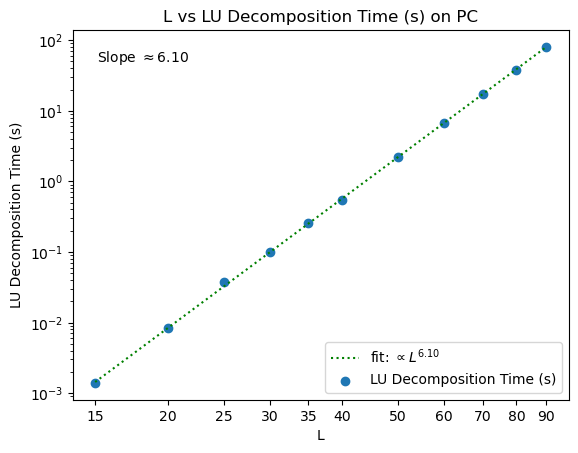

In [12]:
y_key = "LU_time"

plot_loglog_fit(data_dict, y_key, key_vs_label, base_name)

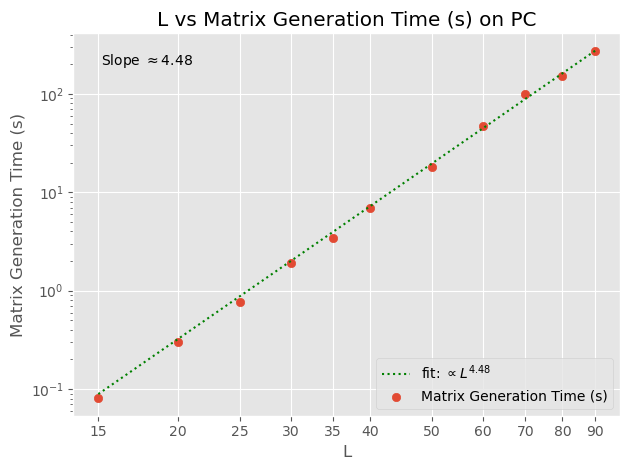

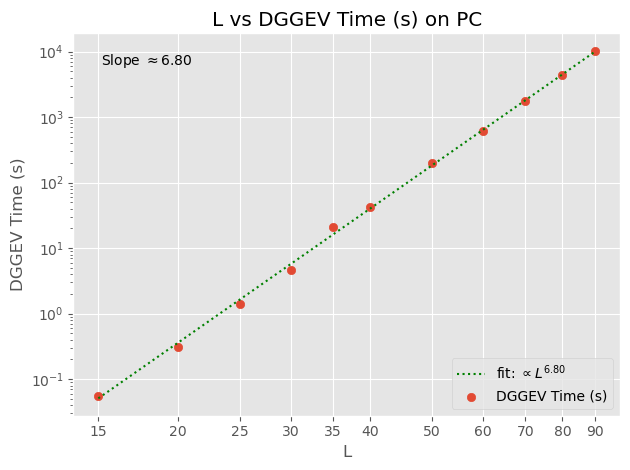

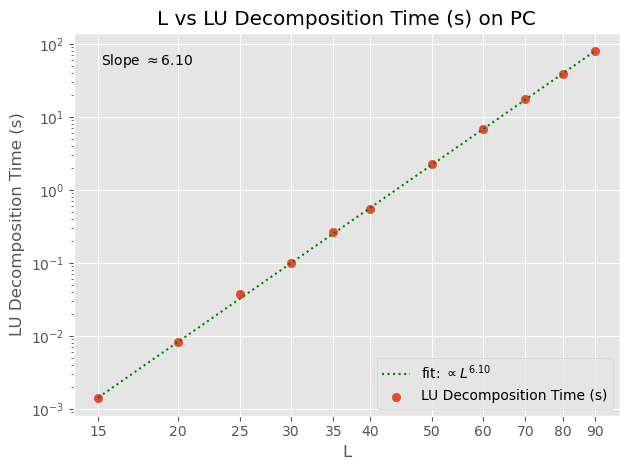

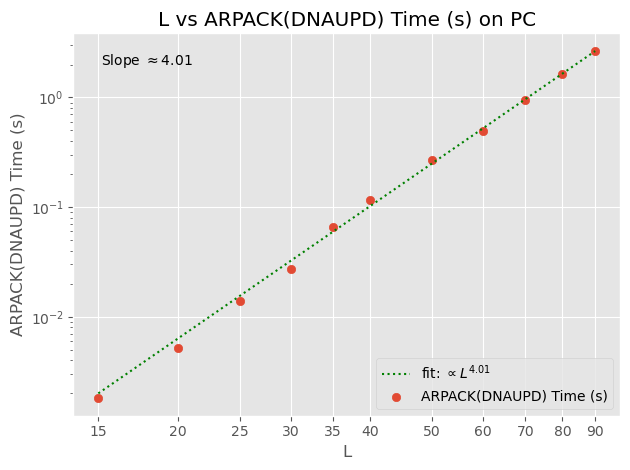

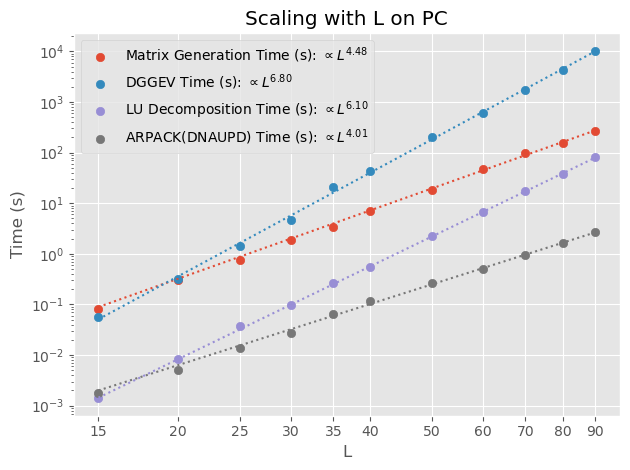

In [13]:
with plt.style.context('ggplot'):
    for y_col in key_vs_label.keys():
        plot_loglog_fit(data_dict, y_col, key_vs_label, base_name)
        plt.tight_layout()
        plt.savefig(save_path / f'{base_name}_{y_col.lower()}.png', dpi=300)  # Save the figure
        # plt.show()
    plot_loglog_fit_all_in_one(data_dict, key_vs_label, base_name)
    plt.tight_layout()
    plt.savefig(save_path / f'{base_name}_all_in_one.png', dpi=300)  # Save the figure

# GET LATEX TABLES from data_dict

In [8]:
# IMPORTANT note that arpack_dnaupd_wrapper_time contains LU_time as well so subtract it to get the pure ARPACK time

base_name , json_timing_data = "PC", Path('pc_timing_data.json')
# base_name , json_timing_data = "HPC", Path('hpc_timing_data.json')


if json_timing_data.exists():
    data_dict = json.load(json_timing_data.open())
    # Keys are strings when read from JSON, convert them back to integers
    data_dict = {int(k): v for k, v in data_dict.items()}
    # get just the timing data for ARPACK by subtracting LU_time from arpack_dnaupd_wrapper_time
    for L, entry in data_dict.items():
        if 'arpack_dnaupd_wrapper_time' in entry and 'LU_time' in entry:
            arpack_time = entry['arpack_dnaupd_wrapper_time']
            lu_time = entry['LU_time']
            pure_arpack_time = [arpack - lu for arpack, lu in zip(arpack_time, lu_time)]
            data_dict[L]['arpack_dnaupd_wrapper_time'] = pure_arpack_time



for L, entry in data_dict.items():
    print(f"{L} & {entry['generate_matrices_time'][0]:.3g} & {entry['LU_time'][0]:.3g} & {entry['arpack_dnaupd_wrapper_time'][0]:.3g} & {entry['dggev_time'][0]:.3g} \\\\")


15 & 0.0809 & 0.00139 & 0.00177 & 0.0464 \\
20 & 0.304 & 0.00827 & 0.0053 & 0.306 \\
25 & 0.761 & 0.0319 & 0.0125 & 1.44 \\
30 & 1.93 & 0.101 & 0.0275 & 5.05 \\
35 & 3.46 & 0.273 & 0.0686 & 21.8 \\
40 & 6.97 & 0.545 & 0.108 & 45.4 \\
50 & 18.2 & 2.18 & 0.269 & 200 \\
60 & 47.5 & 6.7 & 0.503 & 615 \\
70 & 99.9 & 17.2 & 0.954 & 1.77e+03 \\
80 & 153 & 38.4 & 1.64 & 4.34e+03 \\
90 & 274 & 79 & 2.59 & 1.03e+04 \\


In [9]:
# IMPORTANT note that arpack_dnaupd_wrapper_time contains LU_time as well so subtract it to get the pure ARPACK time

# base_name , json_timing_data = "PC", Path('pc_timing_data.json')
base_name , json_timing_data = "HPC", Path('hpc_timing_data.json')


if json_timing_data.exists():
    data_dict = json.load(json_timing_data.open())
    # Keys are strings when read from JSON, convert them back to integers
    data_dict = {int(k): v for k, v in data_dict.items()}
    # get just the timing data for ARPACK by subtracting LU_time from arpack_dnaupd_wrapper_time
    for L, entry in data_dict.items():
        if 'arpack_dnaupd_wrapper_time' in entry and 'LU_time' in entry:
            arpack_time = entry['arpack_dnaupd_wrapper_time']
            lu_time = entry['LU_time']
            pure_arpack_time = [arpack - lu for arpack, lu in zip(arpack_time, lu_time)]
            data_dict[L]['arpack_dnaupd_wrapper_time'] = pure_arpack_time



for L, entry in data_dict.items():
    print(f"{L} & {entry['generate_matrices_time'][0]:.3g} & {entry['LU_time'][0]:.3g} & {entry['arpack_dnaupd_wrapper_time'][0]:.3g} & {entry['dggev_time'][0]:.3g} \\\\")


15 & 0.117 & 0.00244 & 0.00419 & 0.0734 \\
20 & 0.428 & 0.00158 & 0.00286 & 0.301 \\
25 & 1.12 & 0.00594 & 0.00788 & 1.29 \\
30 & 2.77 & 0.015 & 0.0145 & 3.62 \\
35 & 4.76 & 0.0357 & 0.0309 & 9.95 \\
40 & 10.3 & 0.0754 & 0.0646 & 26.4 \\
50 & 26.7 & 0.276 & 0.183 & 125 \\
60 & 71 & 0.806 & 0.404 & 361 \\
70 & 147 & 2.01 & 0.775 & 949 \\
80 & 228 & 4.47 & 1.35 & 3.02e+03 \\
90 & 407 & 9.01 & 2.06 & 5.95e+03 \\
100 & 965 & 18 & 4.7 & 1.31e+04 \\


## Conditioning number vs sigma

In [ ]:
sigma_arr = [1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 5.e-01, 1.e+00, 5.e+00,
        1.e+01, 5.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05]
L15_cond_num = [4.46618175e+08, 4.46715034e+07, 4.46732689e+06, 4.46814123e+05,
        4.71086741e+04, 9.73447953e+03, 4.93084275e+03, 1.06615717e+03,
        5.81691489e+02, 1.93890182e+02, 1.45400376e+02, 1.01756781e+02,
        9.73922814e+01, 9.69558301e+01]
L30_cond_num = [8.97554498e+09, 8.97747916e+08, 8.97770839e+07, 8.97808923e+06,
        9.45259988e+05, 1.94125688e+05, 9.75837602e+04, 1.99125237e+04,
        1.01758664e+04, 2.38192655e+03, 1.40738673e+03, 5.30243143e+02,
        4.42525821e+02, 4.33754060e+02]
L50_cond_num = [7.56291500e+10, 7.56454245e+09, 7.56471590e+08, 7.56483855e+07,
        7.96256966e+06, 1.63335295e+06, 8.19870203e+05, 1.65395830e+05,
        8.33526554e+04, 1.76792172e+04, 9.46752933e+03, 2.07655144e+03,
        1.33746063e+03, 1.26355131e+03]
L80_cond_num = [5.21471550e+11, 5.21583709e+10, 5.21595205e+09, 5.21599218e+08,
        5.48976206e+07, 1.12568271e+07, 5.64775502e+06, 1.13506673e+06,
        5.69368013e+05, 1.16540785e+05, 5.99200831e+04, 8.95807450e+03,
        3.86174272e+03, 3.35214923e+03]

In [ ]:
with plt.style.context('ggplot'):
    plt.scatter(sigma_arr, L15_cond_num, label="L=15")
    plt.scatter(sigma_arr, L30_cond_num, label="L=30")
    plt.scatter(sigma_arr, L50_cond_num, label="L=50")
    plt.scatter(sigma_arr, L80_cond_num, label="L=80")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Sigma")
    plt.ylabel("Condition Number")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path / f'{base_name}_condition_number.png', dpi=300)  # Save the figure

## Num iterations vs sigma

In [ ]:
# sigma , T(s) , std(T), LU solves, std(LU solves)
y_L50 = np.array([[1.00000000e-05, 7.00534564e-02, 1.06765717e-03, 2.10000000e+01,
        0.00000000e+00],
       [1.00000000e-04, 6.94222012e-02, 6.00644924e-04, 2.10000000e+01,
        0.00000000e+00],
       [1.00000000e-03, 6.90376506e-02, 7.37907529e-04, 2.10000000e+01,
        0.00000000e+00],
       [1.00000000e-02, 7.01418386e-02, 1.53112204e-03, 2.10000000e+01,
        0.00000000e+00],
       [1.00000000e-01, 7.01997510e-02, 1.29527652e-03, 2.10000000e+01,
        0.00000000e+00],
       [5.00000000e-01, 1.19242120e-01, 3.42794432e-03, 3.64000000e+01,
        8.00000000e-01],
       [1.00000000e+00, 1.73149106e-01, 1.81361176e-03, 5.30000000e+01,
        0.00000000e+00],
       [5.00000000e+00, 2.82782302e-01, 1.49304028e-03, 8.70000000e+01,
        0.00000000e+00],
       [1.00000000e+01, 3.86736534e-01, 4.16186451e-03, 1.19200000e+02,
        7.48331477e-01],
       [5.00000000e+01, 7.65025020e-01, 1.91684409e-02, 2.35800000e+02,
        5.70613705e+00],
       [1.00000000e+02, 1.06874962e+00, 2.52013666e-02, 3.28200000e+02,
        6.67532771e+00],
       [1.00000000e+03, 2.79263266e+00, 1.28296233e-01, 8.52000000e+02,
        3.95322653e+01],
       [1.00000000e+04, 3.68694200e+00, 1.39871553e-01, 1.11380000e+03,
        3.97763749e+01],
       [1.00000000e+05, 3.36187868e+00, 2.30564831e-01, 1.02380000e+03,
        7.05021985e+01]])

In [ ]:
with plt.style.context('ggplot'):
    plt.scatter(y_L50[:,0], y_L50[:,3], label="")
    plt.xscale("log")
    # plt.yscale("log")
    plt.xlabel("Sigma")
    plt.ylabel("Num LU Solves")
    # plt.legend()
    plt.title("Number of LU Solves needed by ARPACK")
    plt.tight_layout()
    plt.savefig(save_path / 'LU_solve_nums_L50.png', dpi=300)  # Save the figure

# OLD DATA

In [ ]:
# OLD DATA
# L , MatGen , Arpack, LU, dggev
wheeler = [[15 , 0.071161 , 0.000712  , 3.26000e-04, 4.52780000e-02],
[25 , 0.640234 , 0.004513  , 4.48400e-03, 1.46575600e+00],
[35 , 2.72389 , 0.015021  , 3.04950e-02, 2.27840010e+01],
[45 , 9.188617 , 0.094585  , 1.22304e-01, 1.50830308e+02],
[55 , 21.931774 , 0.230849  , 4.14148e-01, 6.44315238e+02]]
wheeler = np.array(wheeler)



pc = [[15, 0.087328 , 0.003085  , 3.623000e-03  , 0.104892],
[25, 0.63935 , 0.017232  , 4.547300e-02  , 1.806011],
[35, 2.83385 , 0.05992   , 3.769910e-01  , 15.621133],
[45, 10.355544 , 0.196789  , 2.010160      , 74.043790],
[55, 21.472547 , 0.481778  , 6.144312      , 275.292717]]
pc = np.array(pc)

labels = ['L', 'MatGen', 'Arpack', 'LU', 'dggev']


In [ ]:
save_path = Path('images/temp').resolve()
save_path

In [ ]:
with plt.style.context('ggplot'):
    plt.scatter(wheeler[:, 0], wheeler[:, 1], label='MatGen')
    plt.yscale('log')
    plt.xscale('log')

In [ ]:
def plot_loglog_fit(data, y_col, ax=None):
    x = data[:, labels.index('L')].astype(float)

    if isinstance(y_col, str):
        y_idx = labels.index(y_col)
        y_label = y_col
    else:
        y_idx = y_col
        y_label = labels[y_idx]

    y = data[:, y_idx].astype(float)
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    weights = np.linspace(1.0, 2.0, len(x))
    slope, intercept = np.polyfit(np.log(x), np.log(y), 1, w=weights)
    fit_y = np.exp(intercept) * x**slope

    if ax is None:
        _, ax = plt.subplots()

    ax.plot(x, fit_y, label=rf'fit: $\propto L^{{{slope:.2f}}}$',linestyle=':',color='green')
    ax.scatter(x, y, label=f'{y_label}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_major_locator(ticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([str(int(val)) for val in x]))
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel('L')
    ax.set_ylabel(y_label)
    ax.set_title(f'L vs {y_label}')
    ax.text(0.05, 0.95, rf'Slope $\approx {slope:.2f}$', transform=ax.transAxes, va='top')
    ax.legend()

    return slope, intercept, ax

In [ ]:
# with plt.style.context('ggplot'):
#     for y_col in ['MatGen', 'Arpack', 'LU', 'dggev']:
#         plot_loglog_fit(wheeler, y_col)
#         plt.savefig(save_path / f'wheeler_{y_col.lower()}.png', dpi=300)  # Save the figure
#         plt.show()

In [ ]:
# with plt.style.context('ggplot'):
#     for y_col in ['MatGen', 'Arpack', 'LU', 'dggev']:
#         plot_loglog_fit(pc, y_col)
#         plt.savefig(save_path / f'pc_{y_col.lower()}.png', dpi=300)  # Save the figure
#         plt.show()

In [ ]:
# with plt.style.context('ggplot'):

#     for data,label in zip([wheeler, pc], ['Wheeler', 'PC']):

#         fig, ax = plt.subplots()

#         for i, y_col in enumerate(['MatGen', 'Arpack', 'LU', 'dggev']):
#             y_idx = labels.index(y_col)
#             x = data[:, labels.index('L')]
#             y = data[:, y_idx]

#             slope, intercept = np.polyfit(np.log(x), np.log(y), 1)
#             fit_y = np.exp(intercept) * x**slope

#             ax.scatter(x, y, label=y_col)
#             ax.plot(x, fit_y, linestyle=':')
#             ax.text(
#                 0.05,
#                 0.95 - 0.08 * i,
#                 rf'{y_col}: slope $\approx {slope:.2f}$',
#                 transform=ax.transAxes,
#                 va='top',
#             )

#         ax.set_xscale('log')
#         ax.set_yscale('log')
#         ax.xaxis.set_major_locator(ticker.FixedLocator(x))
#         ax.xaxis.set_major_formatter(ticker.FixedFormatter([str(int(val)) for val in x]))
#         ax.xaxis.set_minor_locator(ticker.NullLocator())
#         ax.xaxis.set_minor_formatter(ticker.NullFormatter())
#         ax.set_xlabel('L')
#         ax.set_ylabel('Time')
#         ax.set_title('L vs Time')
#         ax.legend()

#         plt.savefig(save_path / f'{label.lower()}_all_loglog.png', dpi=300)
#         plt.show()
